
# Laboratorio 3: Modelo de Detección de Anomalías con ML

**Estudiante:** Hiram Ccoto  
**Curso:** Seguridad Informática  
**Modelo:** Isolation Forest  
**Dataset:** `lab3/network_traffic.csv`

La columna `label` se usa solo para validación, no para entrenamiento.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

DATASET = Path("network_traffic.csv")
MODEL_PATH = Path("modelo_anomalias.pkl")

df = pd.read_csv(DATASET)
df.head()


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
0,2024-05-26 04:28:31,10.0.2.118,201.250.32.133,21,TCP,15310,45067,42.01,16,normal
1,2024-05-11 01:38:15,10.0.1.189,193.199.92.89,21,UDP,3692990,68116,55.35,2823,normal
2,2024-05-17 21:00:41,10.0.3.254,202.222.194.7,443,ICMP,23007,950555,6.64,18,normal
3,2024-05-09 18:30:38,10.0.1.254,152.183.142.33,25,TCP,467423,56148,3.12,656,normal
4,2024-05-27 17:50:29,10.0.3.87,64.39.138.32,3306,UDP,15355,18895,16.82,23,normal



## 3.1 Exploración y preprocesamiento

Se cargan los datos, se revisan estadísticas descriptivas, valores nulos, distribución de variables y se crean nuevas variables derivadas.


In [2]:

print("Dimensiones del dataset:", df.shape)
print("\nInformación del dataset:")
print(df.info())

print("\nEstadísticas descriptivas:")
display(df.describe())

print("\nDistribución de etiquetas:")
print(df["label"].value_counts())

print("\nValores nulos:")
print(df.isnull().sum())


Dimensiones del dataset: (10000, 10)

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     10000 non-null  str    
 1   src_ip        10000 non-null  str    
 2   dst_ip        10000 non-null  str    
 3   dst_port      10000 non-null  int64  
 4   protocol      10000 non-null  str    
 5   bytes_sent    10000 non-null  int64  
 6   bytes_recv    10000 non-null  int64  
 7   duration_sec  10000 non-null  float64
 8   packets       10000 non-null  int64  
 9   label         10000 non-null  str    
dtypes: float64(1), int64(4), str(5)
memory usage: 781.4 KB
None

Estadísticas descriptivas:


,dst_port,bytes_sent,bytes_recv,duration_sec,packets
count,10000.000000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04
mean,5272.963700,2.815289e+07,4.124360e+05,447.154662,1.605501e+04
std,7348.395782,3.115671e+08,1.964278e+06,4530.488171,1.672859e+05
min,21.000000,1.500000e+01,0.000000e+00,0.000000,1.000000e+00
25%,53.000000,5.544000e+03,1.328800e+04,8.507500,5.000000e+00
50%,3389.000000,2.233900e+04,5.529050e+04,21.435000,2.400000e+01
75%,8080.000000,9.478175e+04,2.213258e+05,44.145000,1.100000e+02
max,65460.000000,4.987050e+09,8.155783e+07,83028.150000,2.939448e+06



Distribución de etiquetas:
label
normal     9500
anomaly     500
Name: count, dtype: int64

Valores nulos:
timestamp       0
src_ip          0
dst_ip          0
dst_port        0
protocol        0
bytes_sent      0
bytes_recv      0
duration_sec    0
packets         0
label           0
dtype: int64


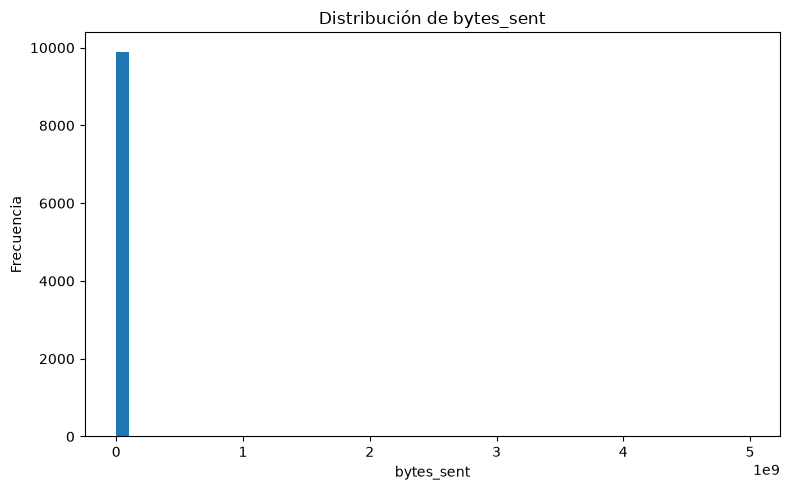

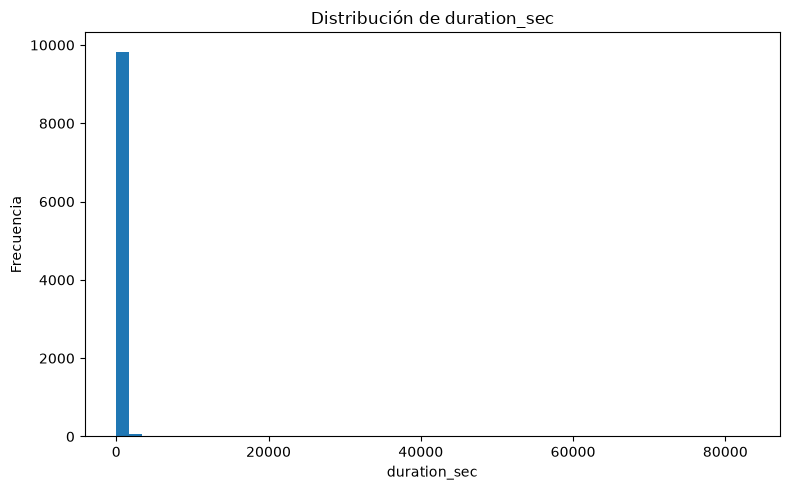

In [3]:

plt.figure(figsize=(8, 5))
plt.hist(df["bytes_sent"], bins=50)
plt.title("Distribución de bytes_sent")
plt.xlabel("bytes_sent")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["duration_sec"], bins=50)
plt.title("Distribución de duration_sec")
plt.xlabel("duration_sec")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


In [4]:

df_proc = df.copy()
df_proc["timestamp"] = pd.to_datetime(df_proc["timestamp"])

numeric_cols_base = ["dst_port", "bytes_sent", "bytes_recv", "duration_sec", "packets"]

# Tratamiento simple de valores extremos usando percentiles 1 y 99
for col in numeric_cols_base:
    p01 = df_proc[col].quantile(0.01)
    p99 = df_proc[col].quantile(0.99)
    df_proc[col] = df_proc[col].clip(lower=p01, upper=p99)

# Feature engineering
df_proc["total_bytes"] = df_proc["bytes_sent"] + df_proc["bytes_recv"]
df_proc["ratio_bytes"] = df_proc["bytes_sent"] / (df_proc["bytes_recv"] + 1)
df_proc["bytes_por_segundo"] = df_proc["total_bytes"] / (df_proc["duration_sec"] + 1)
df_proc["packets_por_segundo"] = df_proc["packets"] / (df_proc["duration_sec"] + 1)
df_proc["hour"] = df_proc["timestamp"].dt.hour

features = pd.get_dummies(
    df_proc[[
        "dst_port", "protocol", "bytes_sent", "bytes_recv",
        "duration_sec", "packets", "total_bytes", "ratio_bytes",
        "bytes_por_segundo", "packets_por_segundo", "hour"
    ]],
    columns=["protocol"],
    drop_first=False
)

feature_columns = list(features.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print("Variables usadas para entrenamiento:")
print(feature_columns)
print("\nShape final:", X_scaled.shape)


Variables usadas para entrenamiento:
['dst_port', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'total_bytes', 'ratio_bytes', 'bytes_por_segundo', 'packets_por_segundo', 'hour', 'protocol_ICMP', 'protocol_TCP', 'protocol_UDP']

Shape final: (10000, 13)



## 3.2 Entrenamiento del modelo

Se entrena Isolation Forest excluyendo `label`. Luego se calculan Precision, Recall, F1-Score y matriz de confusión usando `label` solo como validación.


In [5]:

model = IsolationForest(
    contamination=0.05,
    n_estimators=100,
    random_state=42http://44.222.220.77:8888/notebooks/lab3/deteccion_anomalias.ipynb#3.2-Entrenamiento-del-modelo
)

model.fit(X_scaled)

pred_raw = model.predict(X_scaled)
y_pred_default = np.where(pred_raw == -1, 1, 0)
y_true = np.where(df_proc["label"] == "anomaly", 1, 0)

precision = precision_score(y_true, y_pred_default, zero_division=0)
recall = recall_score(y_true, y_pred_default, zero_division=0)
f1 = f1_score(y_true, y_pred_default, zero_division=0)

print("Métricas con umbral por defecto")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred_default, target_names=["normal", "anomaly"], zero_division=0))


Métricas con umbral por defecto
Precision: 0.5600
Recall:    0.5600
F1-Score:  0.5600

Reporte de clasificación:
              precision    recall  f1-score   support

      normal       0.98      0.98      0.98      9500
     anomaly       0.56      0.56      0.56       500

    accuracy                           0.96     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.96      0.96      0.96     10000



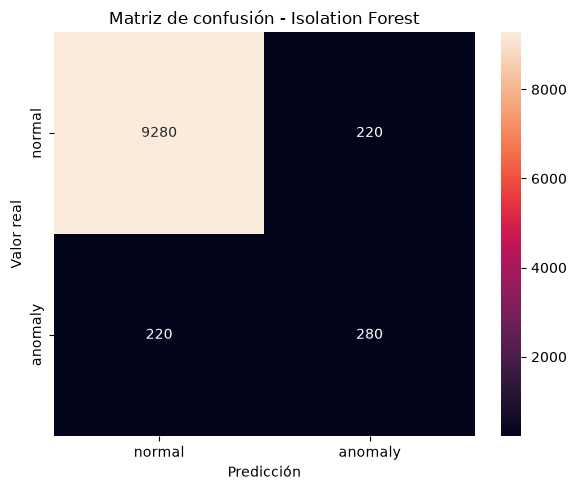

In [6]:

cm = confusion_matrix(y_true, y_pred_default)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["normal", "anomaly"],
    yticklabels=["normal", "anomaly"]
)
plt.title("Matriz de confusión - Isolation Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()



## 3.3 Interpretación y umbral dinámico

Se usa `decision_function` para obtener el score de anomalía. Como Isolation Forest devuelve valores menores para eventos más anómalos, se multiplica por -1 para que un valor mayor indique más anomalía.


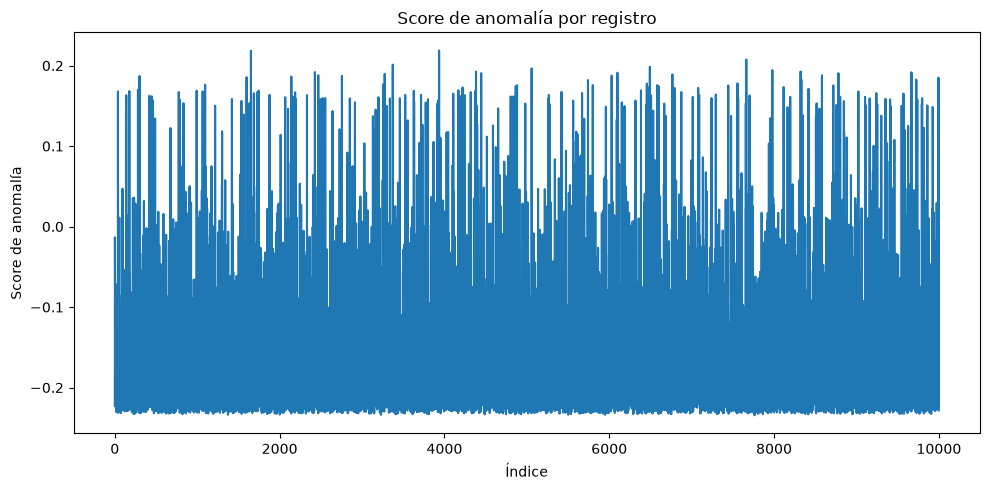

In [7]:

scores_raw = model.decision_function(X_scaled)
anomaly_score = -scores_raw

plt.figure(figsize=(10, 5))
plt.plot(anomaly_score)
plt.title("Score de anomalía por registro")
plt.xlabel("Índice")
plt.ylabel("Score de anomalía")
plt.tight_layout()
plt.show()


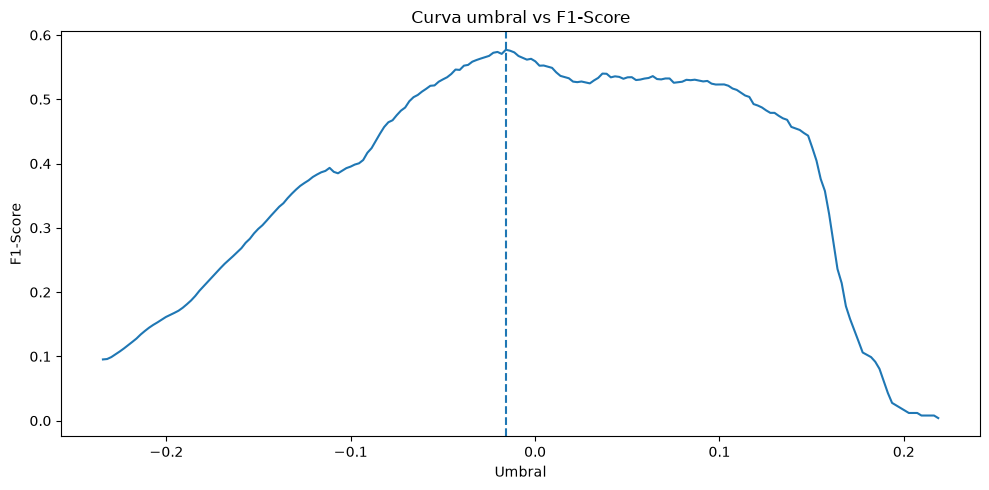

Mejor umbral encontrado: -0.015837
Mejor F1-Score: 0.5771


In [8]:

thresholds = np.linspace(anomaly_score.min(), anomaly_score.max(), 200)
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (anomaly_score >= threshold).astype(int)
    f1_scores.append(f1_score(y_true, y_pred_threshold, zero_division=0))

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, linestyle="--")
plt.title("Curva umbral vs F1-Score")
plt.xlabel("Umbral")
plt.ylabel("F1-Score")
plt.tight_layout()
plt.show()

print(f"Mejor umbral encontrado: {best_threshold:.6f}")
print(f"Mejor F1-Score: {best_f1:.4f}")


Métricas con umbral dinámico
Precision: 0.5255
Recall:    0.6400
F1-Score:  0.5771


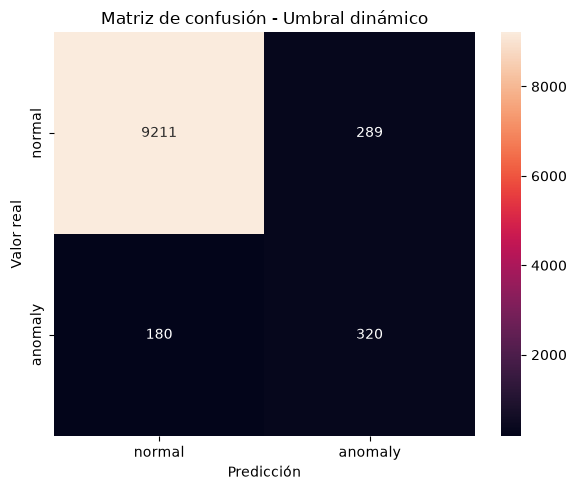

In [9]:

y_pred_opt = (anomaly_score >= best_threshold).astype(int)

precision_opt = precision_score(y_true, y_pred_opt, zero_division=0)
recall_opt = recall_score(y_true, y_pred_opt, zero_division=0)
f1_opt = f1_score(y_true, y_pred_opt, zero_division=0)

print("Métricas con umbral dinámico")
print(f"Precision: {precision_opt:.4f}")
print(f"Recall:    {recall_opt:.4f}")
print(f"F1-Score:  {f1_opt:.4f}")

cm_opt = confusion_matrix(y_true, y_pred_opt)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_opt,
    annot=True,
    fmt="d",
    xticklabels=["normal", "anomaly"],
    yticklabels=["normal", "anomaly"]
)
plt.title("Matriz de confusión - Umbral dinámico")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()


In [10]:

df_resultados = df.copy()
df_resultados["anomaly_score"] = anomaly_score
df_resultados["prediccion"] = np.where(y_pred_opt == 1, "anomaly", "normal")

top10_anomalias = df_resultados.sort_values("anomaly_score", ascending=False).head(10)
display(top10_anomalias)


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label,anomaly_score,prediccion
3935,2024-05-02 05:32:06,10.0.1.206,76.196.246.10,80,ICMP,9992469,230,1.10,67206,anomaly,0.218659,anomaly
1652,2024-05-22 04:24:05,10.0.1.83,134.254.60.66,53,ICMP,8746305,11,7.41,76098,anomaly,0.218354,anomaly
7663,2024-05-16 16:37:46,10.0.1.97,23.129.64.214,53,UDP,9981411,324,6.15,78889,anomaly,0.207532,anomaly
3373,2024-05-30 07:17:09,10.0.1.114,185.220.101.45,53,UDP,9687834,391,5.00,80654,anomaly,0.201187,anomaly
6493,2024-05-29 23:40:17,10.0.3.25,94.184.124.134,80,UDP,5077456,306,1.04,79228,anomaly,0.198499,anomaly
5058,2024-05-05 10:16:01,10.0.3.101,61.47.234.82,53,UDP,7440598,10,5.95,57096,anomaly,0.196507,anomaly
7979,2024-05-06 04:16:50,10.0.2.118,162.247.74.201,443,ICMP,7896912,89,24.24,80643,anomaly,0.194440,anomaly
8322,2024-05-07 02:28:18,10.0.3.75,143.109.217.176,8080,ICMP,4006296316,12306,3330.27,344980,anomaly,0.192678,anomaly
4383,2024-05-19 18:50:37,10.0.3.77,35.150.218.204,443,ICMP,7796140,207,20.30,70952,anomaly,0.192490,anomaly
2428,2024-05-18 01:17:02,10.0.3.25,185.220.101.45,8080,UDP,3381243245,9692,3380.80,1125058,anomaly,0.191992,anomaly



### Interpretación de los Top 10 registros anómalos

Los registros con mayor `anomaly_score` pueden representar amenazas porque combinan comportamientos poco comunes de volumen de datos, duración, paquetes, puertos y protocolo. En un entorno SOC, estos eventos deberían revisarse como posibles casos de exfiltración, escaneo, comunicación irregular o actividad no habitual desde hosts internos.



## 3.4 Exportación del modelo

Se guarda el modelo, el escalador, las columnas usadas y el umbral dinámico para reutilizarlos desde `predecir.py`.


In [11]:

artefacto = {
    "model": model,
    "scaler": scaler,
    "feature_columns": feature_columns,
    "threshold": float(best_threshold)
}

joblib.dump(artefacto, MODEL_PATH)
print(f"Modelo serializado correctamente en: {MODEL_PATH}")


Modelo serializado correctamente en: modelo_anomalias.pkl
